In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [18]:
# Make the corner plot for the MCMC results
system_name = 'HE1113'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [19]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,0.817425,192.4800,-0.317320,0.146400,0.201514,142.4535
1,0.917596,192.5198,-0.318084,0.145746,0.201488,142.3750
2,3.788946,193.1947,-0.319044,0.140757,0.204212,142.4465
3,1.097727,192.7111,-0.319129,0.145457,0.204452,142.4179
4,2.837228,192.7689,-0.320615,0.148743,0.207528,142.4132
...,...,...,...,...,...,...
3508,1.614287,191.9985,-0.317575,0.146554,0.216111,142.3272
3509,6.821485,191.9360,-0.315883,0.140022,0.213901,142.3051
3510,2.687977,191.9728,-0.319144,0.143372,0.214011,142.1640
3511,3.452286,192.1560,-0.322330,0.142337,0.219155,142.1149


In [20]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [21]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

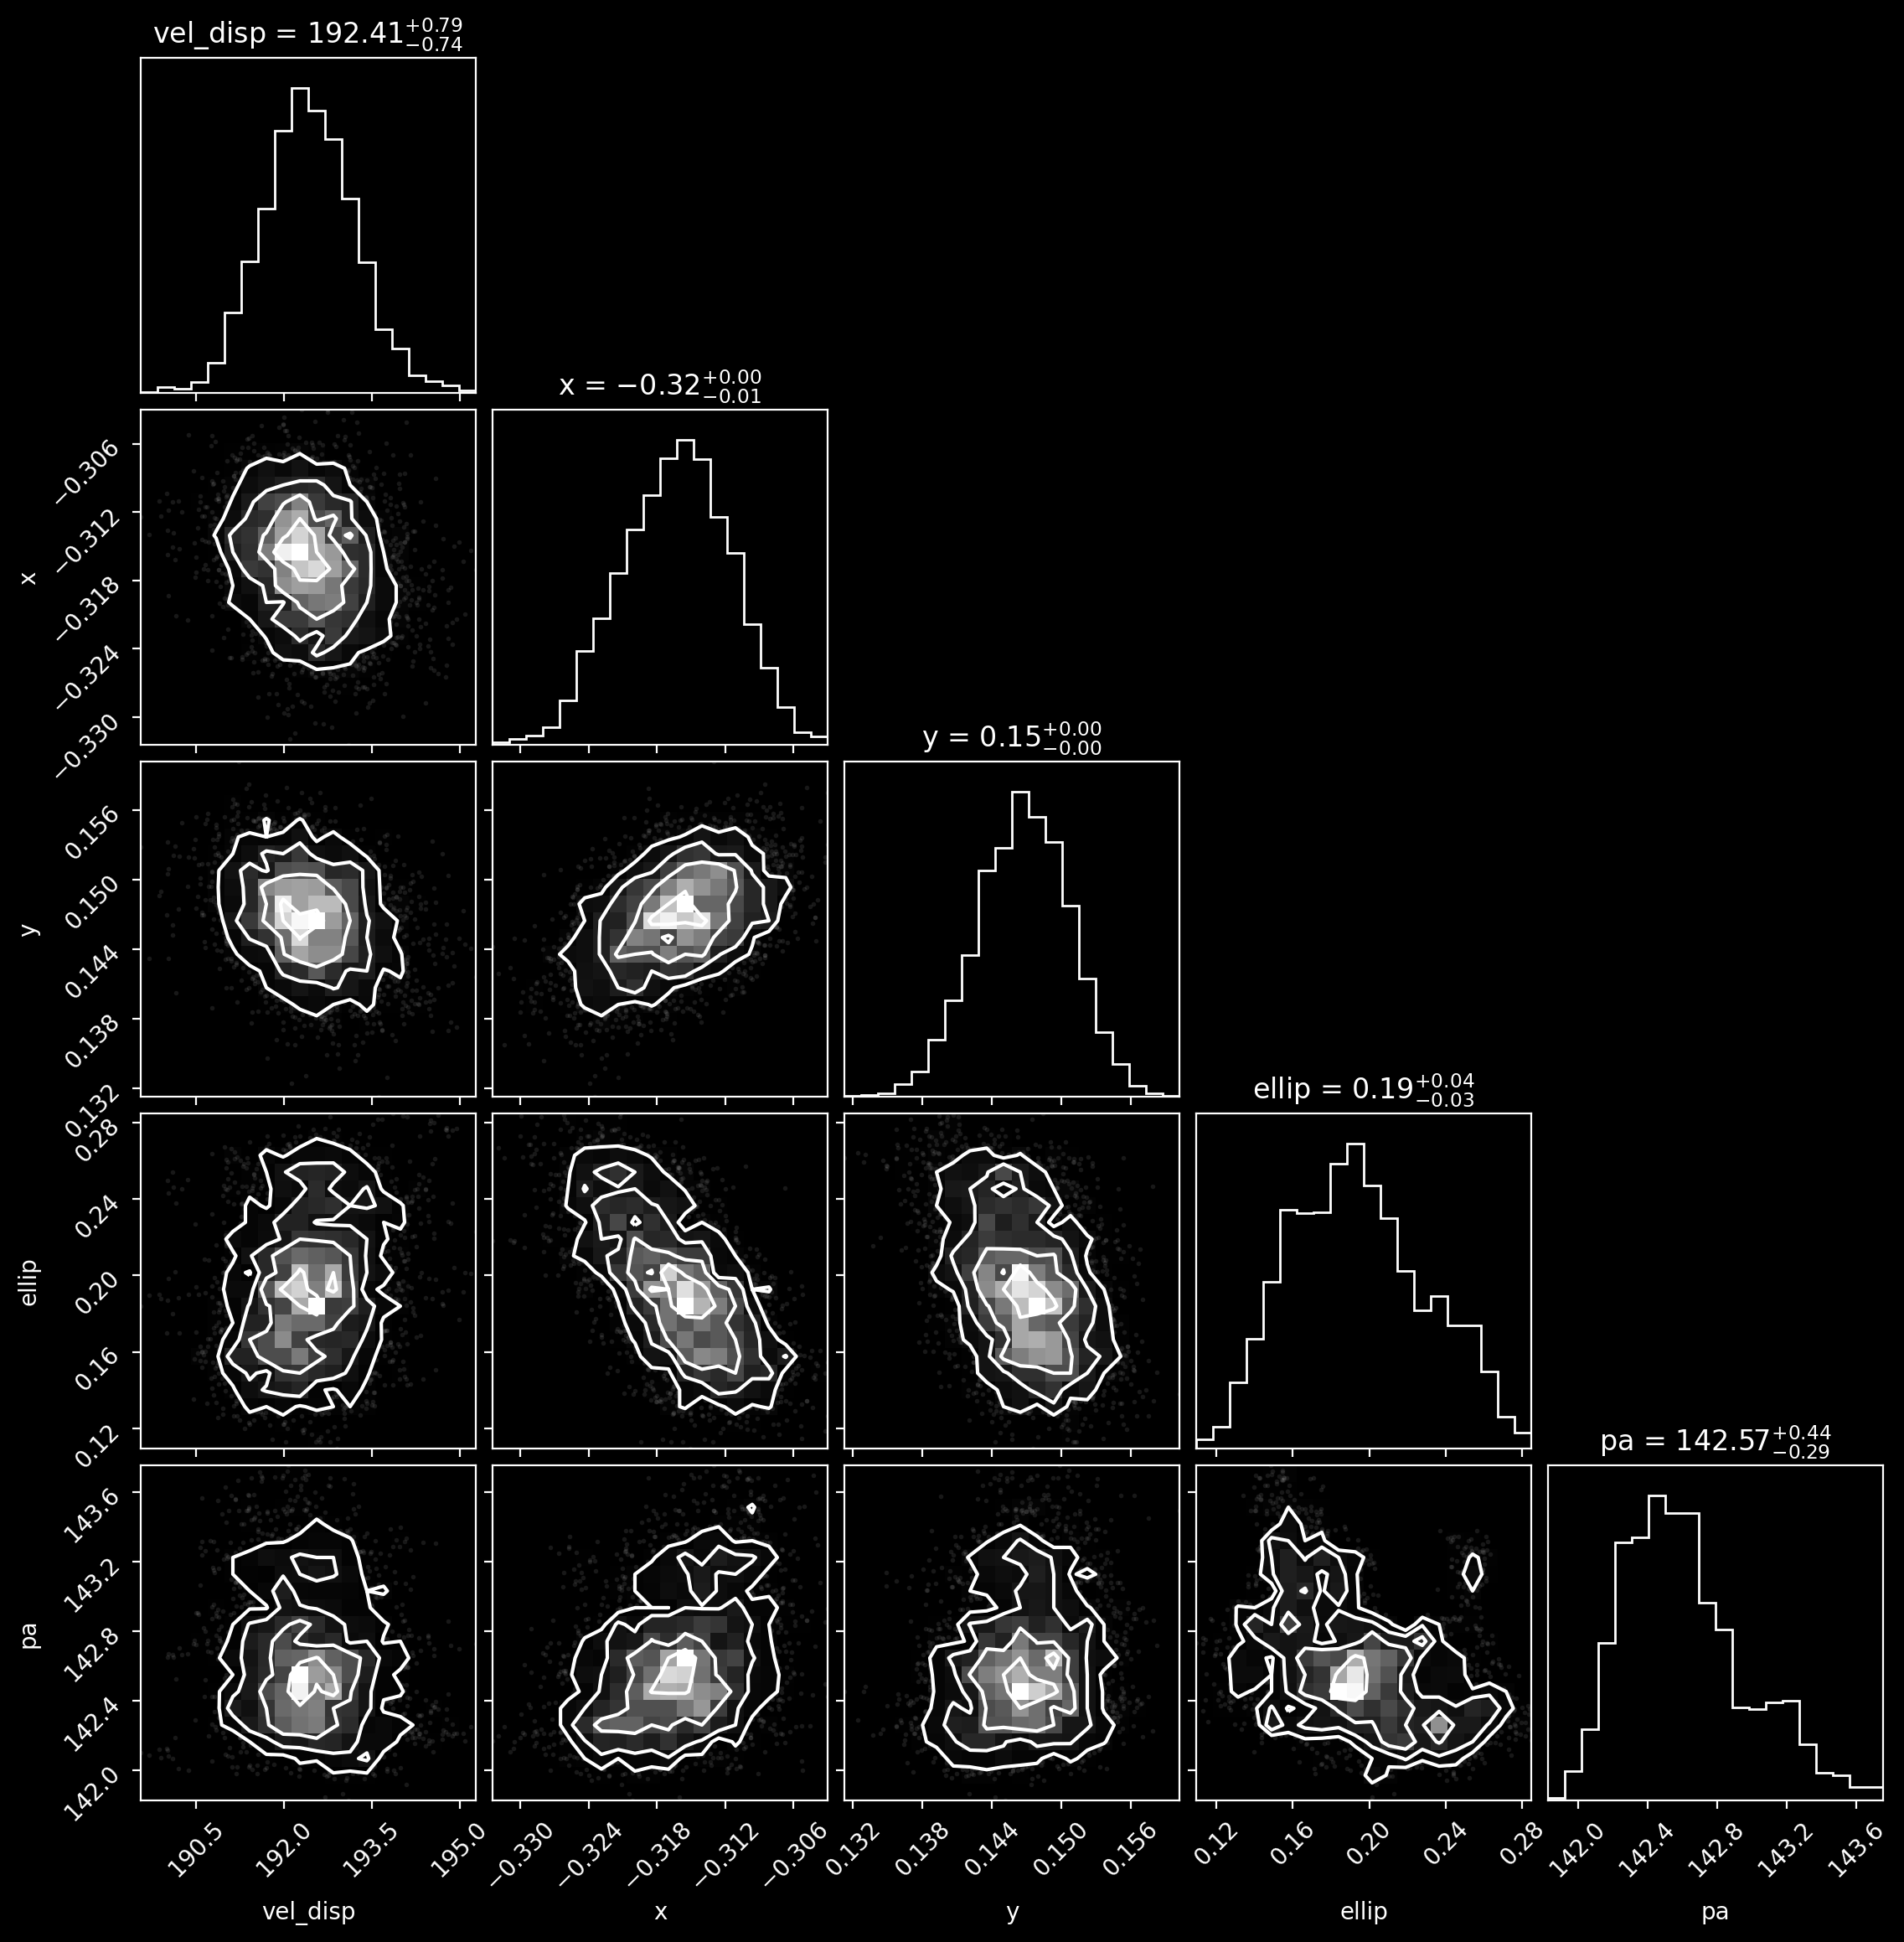

In [22]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')